# Single cell prediction 2.0

Based on the UG Hall 7 cell again but this time incorporating weather data for far more accurate results.

Big question with this whole assignment is what time scale are we predicting - do we want the next 15 mins, do we want the next day in detail, do we want the next week or year?

for long long term such as year can try using the estimates of just statistics - fit it with an ocillitory curve 

### Part 1:


First off:
* Predict the next value only
* RNN and LSTM


In [1]:
# Importing the relevant libraries

import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import optuna
from optuna.trial import TrialState
import seaborn as sns
import json

# Seed for reproducibility

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

**XXXXX**

Note: for this cell below the run time is really long - can it be improved and made more efficient?

**XXXXXX**

In [2]:
# PHASE 1: DATA ENGINEERING & PREPROCESSING
# ==========================================

print("Starting Data Engineering Pipeline...")

# 1. Load and process target data (UG Hall 7)
# Path based on your folder structure
target_path = r"Dataset/Time series dataset/PV generation dataset/PV stations with panel level optimizer/Site level dataset/UG Hall7.csv"

ug_hall = pd.read_csv(target_path, parse_dates=['Time'])
ug_hall = ug_hall[(ug_hall['Time'] >= '2021-01-01') & (ug_hall['Time'] < '2024-01-01')]
ug_hall.set_index('Time', inplace=True)

# Resample target to 15-minute intervals, taking the mean
# (Using '15min' to avoid the Pandas FutureWarning)
ug_hall = ug_hall.resample('15min').mean()

# 2. Define helper function to process weather data from your specific folders
def process_weather_for_year(year):
    base_meteo_path = r"Dataset/Time series dataset/Meteorological dataset"
    
    # Mapping features to their specific folders and files
    files = {
        'Irradiance': os.path.join(base_meteo_path, 'Irradiance', f'Irradiance_{year}.csv'),
        'Relative Humidity': os.path.join(base_meteo_path, 'Relative Humidity', f'Relative Humidity_{year}.csv'),
        'Sea Level Pressure': os.path.join(base_meteo_path, 'Sea Level Pressure', f'Sea Level Pressure_{year}.csv'),
        'Temperature': os.path.join(base_meteo_path, 'Temperature', f'Temperature_{year}.csv'),
        'Visibility': os.path.join(base_meteo_path, 'Visibility', f'Visibility_{year}.csv'),
        'Wind': os.path.join(base_meteo_path, 'Wind', f'Wind_{year}.csv')
    }
    
    # Rainfall has a mix of Excel and CSV formats depending on the year
    if year == 2021:
        files['Rainfall'] = os.path.join(base_meteo_path, 'Rainfall', 'Rainfall_2021.xlsx')
    else:
        files['Rainfall'] = os.path.join(base_meteo_path, 'Rainfall', f'Rainfall_{year}.csv')

    dfs = []
    for feature, filepath in files.items():
        try:
            # Handle the 2021 Excel file anomaly
            if filepath.endswith('.xlsx'):
                df = pd.read_excel(filepath, parse_dates=['Time'])
            else:
                df = pd.read_csv(filepath, parse_dates=['Time'])
                
            df.set_index('Time', inplace=True)
            
            # Convert to numeric, coercing any weird string errors to NaN
            for col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            
            # Resample: Rainfall needs to be Summed, everything else Averaged
            if feature == 'Rainfall':
                df = df.resample('15min').sum()
            else:
                df = df.resample('15min').mean()
                
            dfs.append(df)
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            
    # Concatenate all weather features for the year into one dataframe
    year_data = pd.concat(dfs, axis=1)
    return year_data

# 3. Process weather for all 3 years
print("Processing weather data for 2021, 2022, and 2023...")
weather_2021 = process_weather_for_year(2021)
weather_2022 = process_weather_for_year(2022)
weather_2023 = process_weather_for_year(2023)

# Combine all years
weather_all = pd.concat([weather_2021, weather_2022, weather_2023], axis=0)

# 4. Merge Weather with Target Power Data
merged_all = pd.concat([ug_hall, weather_all], axis=1)

# Slice cleanly to our exact 3-year window
merged_all = merged_all['2021-01-01':'2023-12-31']

# Drop missing values to maintain sequence continuity for the LSTM
merged_all.dropna(inplace=True)

# 5. Feature Engineering: Cyclical Time Encodings
# Neural networks don't understand that 23:59 is 1 minute away from 00:00.
# We map time to Sine and Cosine waves so the model understands the cyclical nature of days and years.
merged_all['Month'] = merged_all.index.month
merged_all['Hour'] = merged_all.index.hour
merged_all['Minute'] = merged_all.index.minute

time_of_day = merged_all['Hour'] + merged_all['Minute'] / 60.0

merged_all['Month_Sin'] = np.sin(2 * np.pi * merged_all['Month'] / 12)
merged_all['Month_Cos'] = np.cos(2 * np.pi * merged_all['Month'] / 12)
merged_all['Time_Sin'] = np.sin(2 * np.pi * time_of_day / 24)
merged_all['Time_Cos'] = np.cos(2 * np.pi * time_of_day / 24)

# Drop the raw time columns as they are now encoded
merged_all.drop(columns=['Month', 'Hour', 'Minute'], inplace=True)

print(f"\nFinal Phase 1 dataset shape: {merged_all.shape}")
print(f"Columns: {merged_all.columns.tolist()}")

# 6. Save the final processed dataset
output_file = 'UGH7_21_23_merged.csv'
merged_all.to_csv(output_file)
print(f"Successfully saved to '{output_file}'!")

Starting Data Engineering Pipeline...
Processing weather data for 2021, 2022, and 2023...

Final Phase 1 dataset shape: (90012, 14)
Columns: ['generation(kWh)', 'power(W)', 'Irradiance (W/m2)', 'RH (%)', 'SLP (hPa)', 'Temp (Degree Celsius)', 'Vis (km)', 'Wind Speed (m/s)', 'Wind Direction (degree)', 'Rainfall(mm)', 'Month_Sin', 'Month_Cos', 'Time_Sin', 'Time_Cos']
Successfully saved to 'UGH7_21_23_merged.csv'!


Above:

data engineering
* combined all the different variables into one CSV for UGHall7
* full 2021-2023
* resampled power data to 15 mins using mean value, so compatible with the weather
* accounted for xl file for rainfall 
* made time cyclical 
* dropped Nans

In [4]:
# NAIVE & DAILY PERSISTENCE BASELINES
# ==========================================

print("Calculating Baselines...")

# Assuming your fully engineered dataset is stored in the variable 'merged_all'
# We create a lightweight copy to avoid altering the main dataset
baseline_df = merged_all[['power(W)']].copy()

# Baseline 1: Naive Persistence (Prediction_{t} = Actual_{t-1})
# "The power in 15 mins will be exactly what it is right now."
baseline_df['pred_15min_ahead'] = baseline_df['power(W)'].shift(1)

# Baseline 2: Daily Persistence (Prediction_{t} = Actual_{t-96})
# "The power right now will be exactly what it was 24 hours ago."
# Since data is at 15-min intervals, 24 hours = 96 steps.
baseline_df['pred_24hr_ahead'] = baseline_df['power(W)'].shift(96)

# Drop rows with NaNs (the first 96 rows) so both models are evaluated 
# on the exact same timeframe for a mathematically fair comparison.
baseline_df.dropna(inplace=True)

# Calculate evaluation metrics (Mean Absolute Error)
mae_15min = (baseline_df['power(W)'] - baseline_df['pred_15min_ahead']).abs().mean()
mae_24hr = (baseline_df['power(W)'] - baseline_df['pred_24hr_ahead']).abs().mean()

# Calculate Root Mean Squared Error
rmse_15min = ((baseline_df['power(W)'] - baseline_df['pred_15min_ahead'])**2).mean()**0.5
rmse_24hr = ((baseline_df['power(W)'] - baseline_df['pred_24hr_ahead'])**2).mean()**0.5

print("--- BASELINE 1: 15-Minute Naive Persistence ---")
print(f"MAE:  {mae_15min:.2f} W")
print(f"RMSE: {rmse_15min:.2f} W\n")

print("--- BASELINE 2: 24-Hour Daily Persistence ---")
print(f"MAE:  {mae_24hr:.2f} W")
print(f"RMSE: {rmse_24hr:.2f} W\n")

print("-" * 50)
print("GOAL: To prove it learned the weather physics, your deep learning model must beat the best of these two baselines!")

Calculating Baselines...
--- BASELINE 1: 15-Minute Naive Persistence ---
MAE:  640.13 W
RMSE: 1579.28 W

--- BASELINE 2: 24-Hour Daily Persistence ---
MAE:  1421.80 W
RMSE: 3304.23 W

--------------------------------------------------
GOAL: To prove it learned the weather physics, your deep learning model must beat the best of these two baselines!


Above:

Baseline testing

using a naive and seasonal persistance model

Naive: $Pred_t = Act_{t-1} $ i.e. prediction of power is what it was just now

Daily : $ Pred_t = Act_{t-96} $ i.e. prediction of power is what it was this time yesterday

In [5]:
# Dataloader function
def create_dataloaders(
    df,
    target_col='power(W)',
    exclude_cols=['generation(kWh)'],
    seq_length=48,
    train_end_date='2023-01-01',
    test_end_date='2023-06-01',
    batch_size=64,
    scaler=None,
    shuffle_train=True,
    pin_memory=False,
    num_workers=0
):
    df_copy = df.copy()
    
    if not pd.api.types.is_datetime64_any_dtype(df_copy.index):
        df_copy.index = pd.to_datetime(df_copy.index, format='mixed', dayfirst=True)

    features = [col for col in df_copy.columns if col not in exclude_cols]
    target_idx = features.index(target_col)

    if scaler is None:
        scaler = MinMaxScaler()
        
    scaled_data = scaler.fit_transform(df_copy[features].values)

    xs, ys, indices = [], [], []
    for i in range(len(scaled_data) - seq_length):
        xs.append(scaled_data[i : i + seq_length])
        ys.append(scaled_data[i + seq_length, target_idx])
        indices.append(df_copy.index[i + seq_length])

    X, y = np.array(xs), np.array(ys)
    dates = pd.DatetimeIndex(indices)

    t_split = pd.Timestamp(train_end_date)
    v_split = pd.Timestamp(test_end_date)
    
    train_mask = dates < t_split
    test_mask = (dates >= t_split) & (dates < v_split)
    val_mask = dates >= v_split

    def to_tensor(mask):
        return (
            torch.tensor(X[mask], dtype=torch.float32),
            torch.tensor(y[mask], dtype=torch.float32).unsqueeze(-1)
        )

    X_train, y_train = to_tensor(train_mask)
    X_test, y_test = to_tensor(test_mask)
    X_val, y_val = to_tensor(val_mask)

    train_loader = DataLoader(
        TensorDataset(X_train, y_train), 
        batch_size=batch_size, 
        shuffle=shuffle_train, 
        pin_memory=pin_memory, 
        num_workers=num_workers
    )
    
    test_loader = DataLoader(
        TensorDataset(X_test, y_test), 
        batch_size=batch_size, 
        shuffle=False, 
        pin_memory=pin_memory, 
        num_workers=num_workers
    )
    
    val_loader = DataLoader(
        TensorDataset(X_val, y_val), 
        batch_size=batch_size, 
        shuffle=False, 
        pin_memory=pin_memory, 
        num_workers=num_workers
    )

    return train_loader, test_loader, val_loader, scaler, features, target_idx

Above:

Data preprocessing for 15 min prediction
* makes sure the date and time is read correctly - check if needed, I think the cell above does that enough
* Drops the generation column as we want to predict the power column and generation is no use for helping predict it - is that data leakage?
* scales so all values have the same range, means model values them all equally. 
* sequences over the data to produce sets of 48 inputs with the next one as an output, ready for use in the ml model

Above:

Training data creation
* splits the train and test and validation - uses 66:17:17 at the moment, maybe more train needed but sits nicely on the year mark
* converts to tensor and then dataloads for use in training
* criterion is MSE, very appropriate as we have scaled all the values to 1

In [6]:
# Training function

"""

Cell generated by Gemini 3.1 Pro using prompt:

'I want to combine my training into a single function so that I can train 
multiple models within my notebook without having to rewrite the training script.
I want it to be generalisable though, make it have as many parameters as possible
even though most can be goven default values'

It was further edited by me

"""

def train_model(
    model,
    train_loader,
    test_loader=None,
    val_loader=None,
    criterion=None,
    optimizer_class=torch.optim.Adam,
    lr=0.001,
    weight_decay=0.0,
    epochs=50,
    device='cpu',
    patience=5,
    save_best_model=True,
    model_save_path="best_model.pth",
    verbose=1,
    optuna_trial=None
):
    """
    A highly generalized PyTorch training loop for time-series models.
    
    Parameters:
    - model: The PyTorch neural network to train.
    - train_loader: DataLoader for the training set.
    - val_loader: DataLoader for the validation set (used for early stopping).
    - criterion: Loss function (defaults to nn.MSELoss()).
    - optimizer_class: The PyTorch optimizer class (defaults to Adam).
    - lr: Learning rate.
    - weight_decay: L2 regularization penalty (helps prevent overfitting).
    - epochs: Maximum number of epochs to train.
    - device: 'cuda' or 'cpu'. Defaults to auto-detect.
    - patience: Epochs to wait for improvement before Early Stopping (Set to None to disable).
    - save_best_model: Whether to save the weights of the lowest val_loss epoch.
    - model_save_path: Filepath to save the best model weights.
    - gradient_clip: Max norm for gradients (prevents exploding gradients in LSTMs).
    - verbose: How often to print epoch updates (1 = every epoch, 0 = silent).
    - optuna_trial: Pass the `trial` object if running inside an Optuna sweep for pruning.
    
    Returns:
    - model: The trained model (loaded with the best weights if early stopping triggered).
    - history: Dictionary containing lists of 'train_loss' and 'val_loss' over epochs.
    """
    
    # --- 1. Initialization ---
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model = model.to(device)
    
    if criterion is None:
        criterion = nn.MSELoss()
        
    optimizer = optimizer_class(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'test_loss': []}
    best_test_loss = float('inf')
    trigger_times = 0
    
    if verbose > 0:
        print(f"Starting training on {device} for up to {epochs} epochs...")

    # --- 2. Main Epoch Loop ---
    for epoch in range(epochs):
        # 1. Training Phase
        model.train()
        train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
            
        train_loss = train_loss / len(train_loader.dataset)

        eval_metric = nn.L1Loss()
            
        # 2. Testing/Monitoring Phase (Per Epoch)
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                test_loss += eval_metric(outputs, targets).item() * inputs.size(0)
                
        test_loss = test_loss / len(test_loader.dataset)
        
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
            
        # -- Logging --
        if verbose > 0:
            log_msg = f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.6f}"
            if test_loss is not None:
                log_msg += f" | Test Loss: {test_loss:.6f}"
            print(log_msg)
            
        # -- Optuna Pruning --
        if optuna_trial is not None and test_loss is not None:
            optuna_trial.report(test_loss, epoch)
            if optuna_trial.should_prune():
                if verbose > 0:
                    print(f"Trial pruned by Optuna at epoch {epoch+1}")
                raise optuna.TrialPruned()
                
        # -- Early Stopping & Model Checkpointing --
        if test_loss is not None:
            if test_loss < best_test_loss:
                best_test_loss = test_loss
                trigger_times = 0
                if save_best_model:
                    torch.save(model.state_dict(), model_save_path)
            else:
                trigger_times += 1
                if patience is not None and trigger_times >= patience:
                    if verbose > 0:
                        print(f"Early stopping triggered! No improvement for {patience} epochs.")
                    break
                    
    # --- 3. Finalization ---
    # Load the best weights back into the model before returning it
    if save_best_model and val_loader is not None and os.path.exists(model_save_path):
        model.load_state_dict(torch.load(model_save_path))
        if verbose > 0:
            print(f"Restored best model weights (Test Loss: {best_test_loss:.6f})")
            
    return model, history


### Performing hyperparameter optimisation

In [7]:
# Load data for optuna

print("Loading data...")
df = merged_all.copy()
df.index = pd.to_datetime(df.index, format='mixed', dayfirst=True)

# Select features
features = [col for col in df.columns if col != 'generation(kWh)']
target_col = 'power(W)'
target_idx = features.index(target_col)

# Train/Val Split (Train on 2021 to 2022, Validate on early-2022, test on later-2022)
train_df = df.loc['2021-01-01':'2021-12-31']
test_df = df.loc['2022-01-01':'2022-05-31']
val_df = df.loc['2022-06-01':'2022-12-31']


# Scale
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[features].values).astype(np.float32)
val_scaled = scaler.transform(val_df[features].values).astype(np.float32)
test_scaled = scaler.transform(test_df[features].values).astype(np.float32)

print('Done :)')

Loading data...
Done :)


In [8]:
# Create class to make datasets on the fly
class DynamicSequenceDataset(Dataset):
    def __init__(self, data, seq_length, target_idx):
        self.data = data
        self.seq_length = seq_length
        self.target_idx = target_idx

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_length]
        y = self.data[idx + self.seq_length, self.target_idx]
        return torch.tensor(x), torch.tensor([y])


In [9]:
# Flexible Model (Can be LSTM or GRU)
class FlexibleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, rnn_type, dropout):
        super(FlexibleRNN, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.rnn_type = rnn_type
        
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
            
        self.fc = nn.Linear(hidden_size, 1) # Sequence-to-One
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        if self.rnn_type == 'LSTM':
            c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
            out, _ = self.rnn(x, (h0, c0))
        else:
            # GRU does not have a cell state (c0)
            out, _ = self.rnn(x, h0)
            
        out = self.fc(out[:, -1, :])
        return out

In [10]:
# 4. Optuna Objective Function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
INPUT_SIZE = len(features)

def objective(trial):
    # --- HYPERPARAMETER SEARCH SPACE ---
    # 1. Architecture
    rnn_type = trial.suggest_categorical("rnn_type", ["LSTM", "GRU"])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    hidden_size = trial.suggest_categorical("hidden_size",[32, 64, 128, 256])
    
    # PyTorch throws an error if dropout > 0 but num_layers == 1
    dropout = trial.suggest_float("dropout", 0.1, 0.4) if num_layers > 1 else 0.0
    
    # 2. Sequence Length
    seq_length = trial.suggest_categorical("seq_length",[24, 48, 96, 144, 192, 384])
    
    # 3. Learning Rate
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    
    # 4. Tune the Training Loss Function
    loss_type = trial.suggest_categorical("loss_type", ["MSE", "MAE", "Huber"])
    if loss_type == "MSE":
        train_criterion = nn.MSELoss()
    elif loss_type == "MAE":
        train_criterion = nn.L1Loss()
    else:
        train_criterion = nn.HuberLoss()
    
    # --- BUILD DATALOADERS DYNAMICALLY ---
    train_dataset = DynamicSequenceDataset(train_scaled, seq_length, target_idx)
    test_dataset = DynamicSequenceDataset(test_scaled, seq_length, target_idx)
    val_dataset = DynamicSequenceDataset(val_scaled, seq_length, target_idx)
    
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
    
    # --- INIT MODEL ---
    model = FlexibleRNN(INPUT_SIZE, hidden_size, num_layers, rnn_type, dropout).to(device)
    
    # --- TRAIN USING GENERALIZED FUNCTION ---
    trained_model, history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        val_loader=val_loader, 
        criterion=train_criterion,  # Pass the dynamically chosen loss function
        lr=lr,
        epochs=20,
        device=device,
        patience=3,
        verbose=0, 
        optuna_trial=trial
    )

    # --- FINAL VALIDATION PHASE (Post-Training) ---
    # Evaluate the fully trained model on unseen validation data
    trained_model.eval()
    
    # INDEPENDENT METRIC: Always use MAE to rank the final trial fairly
    eval_criterion = nn.L1Loss() 
    val_loss_sum = 0.0
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = trained_model(inputs)
            val_loss_sum += eval_criterion(outputs, targets).item() * inputs.size(0)
            
    final_val_mae = val_loss_sum / len(val_dataset)
    
    # Return the uniform MAE metric back to Optuna
    return final_val_mae

NOTE: 

Below is using optuna tree-structured parzen estimator - bayesian optimisation 

very efficient and very good - far better than grid search

utilises harsher pruning too - uses a tournerment style pruning where it starts 9 at once and then kills off the bottom 
2/3 after a bit and so on

also uses a smaller training size for optuna - 1 year of data not 2+

In [12]:
# HYPERPARAMETER TUNING TOGGLE
# ==========================================

# Run optimisation: ON!
RUN_OPTUNA_SWEEP = False

if RUN_OPTUNA_SWEEP:
    print("Initiating Optuna Hyperparameter Sweep...")
    
    # We use a deterministic seed so the marker gets the exact same results if they do run it
    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=optuna.pruners.HyperbandPruner(min_resource=2, reduction_factor=3))

    # Run for a specified number of trials
    study.optimize(objective, n_trials=1)
    
    print("\n--- OPTIMIZATION COMPLETE ---")
    print("Best Trial Value (MAE):", study.best_value)
    print("Best Parameters:")
    
    # This prints a dictionary you can literally copy and paste into the 'else' block
    best_params = study.best_params
    print(json.dumps(best_params, indent=4))

else:
    print("Skipping multi-hour Optuna sweep.")
    print("Loading pre-computed optimal hyperparameters to save compute time...")
    
    # REPLACE THIS DICTIONARY with the output printed from your actual run!
    best_params = {
        "rnn_type": "GRU",
        "num_layers": 3,
        "hidden_size": 32,
        "dropout": 0.3598528437324806,
        "seq_length": 144,
        "lr": 0.0002310201887845295,
        "loss_type": "Huber"
    }

print("\nActive Hyperparameters for Final Training:")
for key, value in best_params.items():
    print(f" - {key}: {value}")

Skipping multi-hour Optuna sweep.
Loading pre-computed optimal hyperparameters to save compute time...

Active Hyperparameters for Final Training:
 - rnn_type: GRU
 - num_layers: 3
 - hidden_size: 32
 - dropout: 0.3598528437324806
 - seq_length: 144
 - lr: 0.0002310201887845295
 - loss_type: Huber


In [ ]:
# Calling dataloader function
train_loader, test_loader, val_loader, scaler, features, target_idx = create_dataloaders(
    df=merged_all,
    seq_length=best_params['seq_length'],
    batch_size=64
)

Starting training on cpu for up to 1 epochs...
Epoch [1/1] | Train Loss: 0.008644 | Test Loss: 0.037661
Restored best model weights (Test Loss: 0.037661)


C:\Users\Jpjha\AppData\Local\Temp\ipykernel_23780\1635469138.py:140: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_save_path))


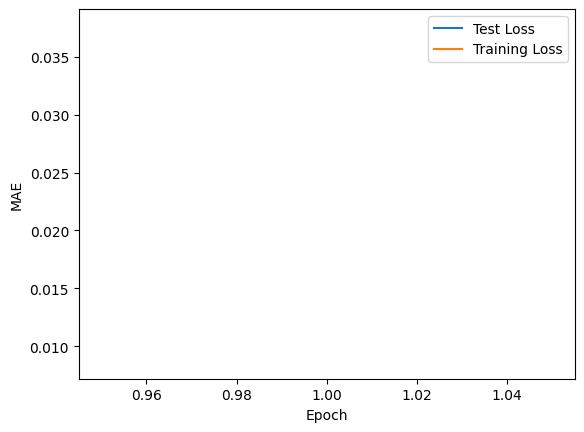

In [ ]:
input_size = len(features)

if best_params['loss_type'] == 'MSE':
    criterion = nn.MSELoss()
elif best_params['loss_type'] == 'L1loss':
    criterion = nn.L1Loss()
else:
    criterion = nn.HuberLoss()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FlexibleRNN(input_size, best_params['hidden_size'], best_params['num_layers'], best_params['rnn_type'], best_params['dropout']).to(device)
num_epochs = 1

model, history = train_model(model = model, train_loader= train_loader, test_loader= test_loader, val_loader= val_loader, criterion= criterion, lr = best_params['lr'], epochs = num_epochs)

plt.plot(range(1, len(history['test_loss'])+1), history['test_loss'], label = 'Test Loss')
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], label = 'Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()


Above:

Model and training
* Defines an RNN with LSTM - learn more detail about the architecture 
* trains the model and plots the losses


Average Validation MSE: 0.002945
Average Validation NMAE: 7.32%


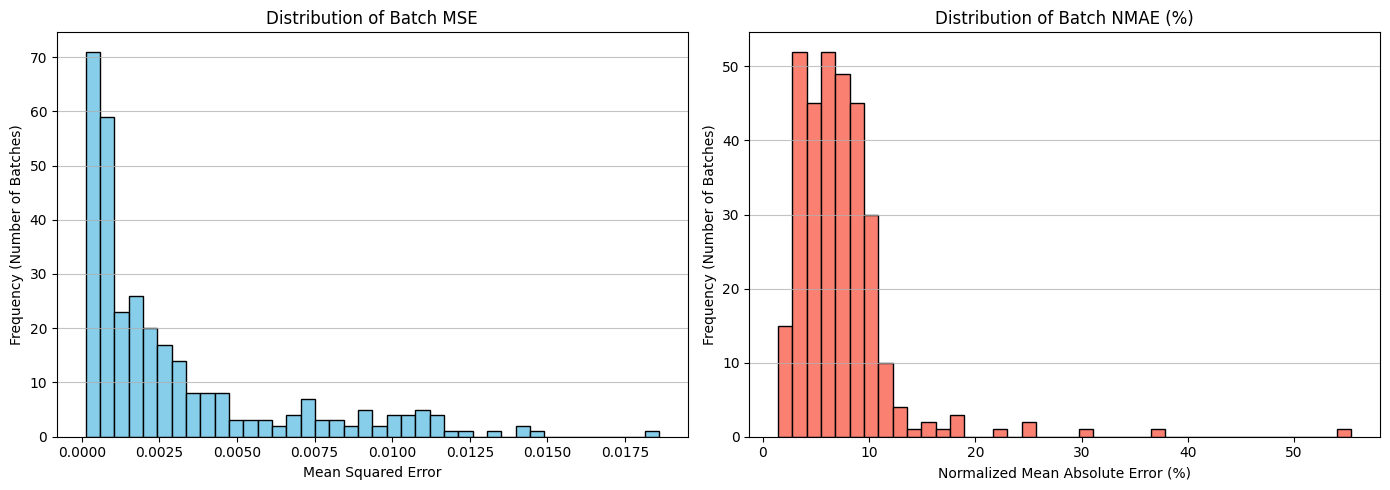

In [16]:
# 8. Final validation evaluation - of unoptimised model
# ==========================================

model.eval()
val_mse_list = []
val_nmae_list = []

with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(val_loader, start=1):
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)

        # MSE in scaled space
        batch_mse = criterion(outputs, targets).item()
        val_mse_list.append(batch_mse)

        # NMAE in original power units (Watts)
        preds_batch = outputs.cpu().numpy().flatten()
        actuals_batch = targets.cpu().numpy().flatten()

        dummy_preds = np.zeros((len(preds_batch), len(features)))
        dummy_actuals = np.zeros((len(actuals_batch), len(features)))
        dummy_preds[:, target_idx] = preds_batch
        dummy_actuals[:, target_idx] = actuals_batch

        preds_unscaled = scaler.inverse_transform(dummy_preds)[:, target_idx]
        actuals_unscaled = scaler.inverse_transform(dummy_actuals)[:, target_idx]
        preds_unscaled = np.maximum(preds_unscaled, 0)

        batch_mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
        batch_peak = np.max(actuals_unscaled)

        if batch_peak > 0:
            batch_nmae = (batch_mae / batch_peak) * 100
        else:
            batch_nmae = np.nan

        val_nmae_list.append(batch_nmae)
        
        # ---> REMOVED the per-batch print statement here <---

# Calculate averages
avg_val_mse = float(np.nanmean(val_mse_list))
avg_val_nmae = float(np.nanmean(val_nmae_list))

# Print only the final averages
print(f"\nAverage Validation MSE: {avg_val_mse:.6f}")
print(f"Average Validation NMAE: {avg_val_nmae:.2f}%")

# ==========================================
# Plotting the Error Histograms
# ==========================================

# Filter out any NaN values from NMAE list so matplotlib doesn't complain
clean_nmae_list = [x for x in val_nmae_list if not np.isnan(x)]

# Create a figure with two subplots side-by-side
plt.figure(figsize=(14, 5))

# Plot 1: Histogram for MSE
plt.subplot(1, 2, 1)
plt.hist(val_mse_list, bins=40, color='skyblue', edgecolor='black')
plt.title('Distribution of Batch MSE')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency (Number of Batches)')
plt.grid(axis='y', alpha=0.75)

# Plot 2: Histogram for NMAE
plt.subplot(1, 2, 2)
plt.hist(clean_nmae_list, bins=40, color='salmon', edgecolor='black')
plt.title('Distribution of Batch NMAE (%)')
plt.xlabel('Normalized Mean Absolute Error (%)')
plt.ylabel('Frequency (Number of Batches)')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

Above:

Tests the model on the validation data
* returns the MSE and NMAE for each batch aswell as the whole validation set
* 7.9% seems decent but hard to say for sure

going to need to adapt this - this is validating it on the 2023 data but its already seen it all 

Average Percentage Deviation (MAPE - Daylight hours only): 144.40%
Mean Absolute Error (MAE - All hours): 678.79 Watts
Normalised Mean Absolute Error (NMAE - All hours): 2.72


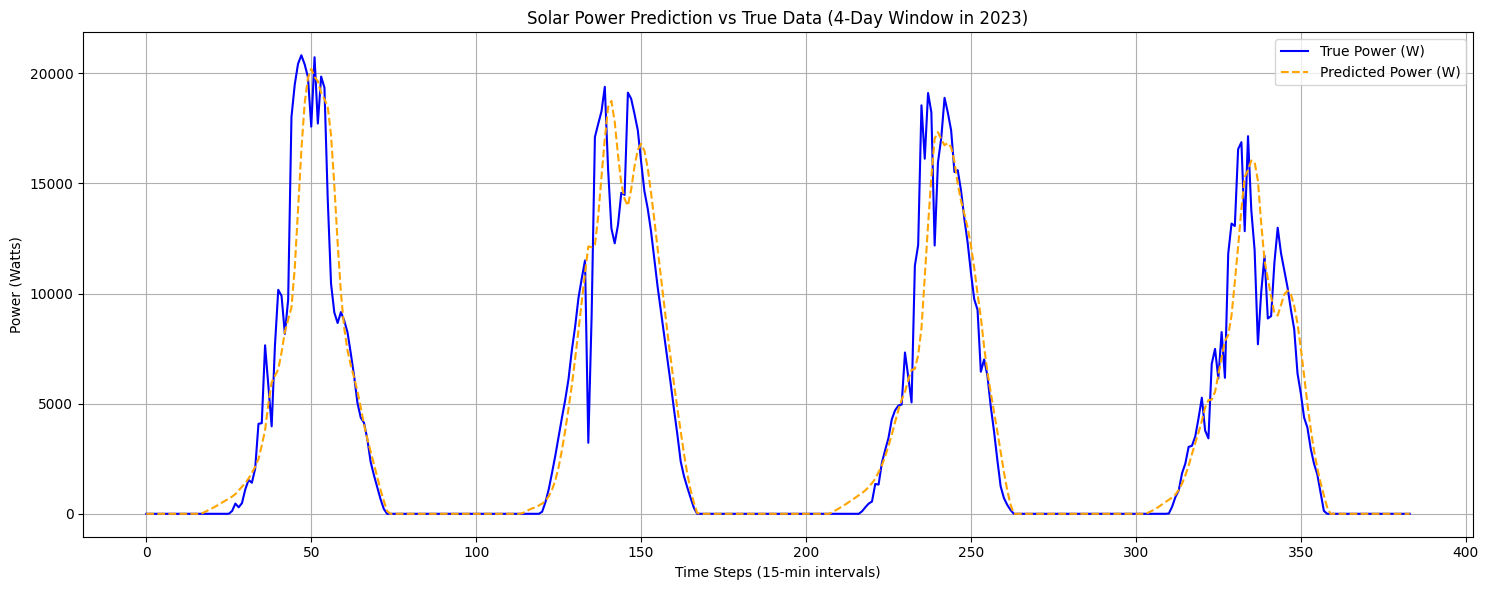

In [22]:
# Plot as a few days - good visualisation - little misleading
# 1. Gather Predictions and Actuals from the 2023 Test Set
model.eval()
all_preds = []
all_actuals = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        
        # Move back to CPU and convert to numpy
        all_preds.append(outputs.cpu().numpy())
        all_actuals.append(targets.cpu().numpy())

# Flatten lists
preds_array = np.concatenate(all_preds).flatten()
actuals_array = np.concatenate(all_actuals).flatten()

# 2. Inverse Transform to Original Scale (Watts)
# Create dummy arrays matching the exact number of features used during scaling
num_features = len(features)
dummy_preds = np.zeros((len(preds_array), num_features))
dummy_actuals = np.zeros((len(actuals_array), num_features))

# Place the predictions/actuals into the correct target column index
dummy_preds[:, target_idx] = preds_array
dummy_actuals[:, target_idx] = actuals_array

# Inverse transform and extract just the target column
preds_unscaled = scaler.inverse_transform(dummy_preds)[:, target_idx]
actuals_unscaled = scaler.inverse_transform(dummy_actuals)[:, target_idx]

# Ensure no negative predictions (solar power cannot physically be negative)
preds_unscaled = np.maximum(preds_unscaled, 0)

# 3. Calculate Validation Metrics
# Filter out nighttime / zero-power data to avoid Division by Zero
daylight_mask = actuals_unscaled > 1.0

if np.sum(daylight_mask) > 0:
    mape = np.mean(np.abs((actuals_unscaled[daylight_mask] - preds_unscaled[daylight_mask]) / actuals_unscaled[daylight_mask])) * 100
    print(f"Average Percentage Deviation (MAPE - Daylight hours only): {mape:.2f}%")
else:
    print("Not enough daylight data to calculate meaningful percentage deviation.")

mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
nmae = (mae / actuals_unscaled.max()) * 100
print(f"Mean Absolute Error (MAE - All hours): {mae:.2f} Watts")
print(f"Normalised Mean Absolute Error (NMAE - All hours): {nmae:.2f}")

# 4. Visualization (Plotting a 4-day window)
# 96 steps per day. Let's start at index 96 * 100 (approx 100 days into 2023, mid-April) 
# to see some good spring/summer generation curves.
START_IDX = 96 * 100
PLOT_WINDOW = 96 * 4  # 4 days

# Safely handle if the test set is shorter than expected
if START_IDX + PLOT_WINDOW > len(actuals_unscaled):
    START_IDX = 0

plt.figure(figsize=(15, 6))
plt.plot(actuals_unscaled[START_IDX : START_IDX + PLOT_WINDOW], label='True Power (W)', color='blue', linewidth=1.5)
plt.plot(preds_unscaled[START_IDX : START_IDX + PLOT_WINDOW], label='Predicted Power (W)', color='orange', linestyle='--', linewidth=1.5)

plt.title('Solar Power Prediction vs True Data (4-Day Window in 2023)')
plt.xlabel('Time Steps (15-min intervals)')
plt.ylabel('Power (Watts)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Above:

I believe this just applies the model to a significant chunk of data and then visualises it

visualisation plot is a little misleading as the model is only acutally predicting the next 15 minuite interval

I think this experiences data leakage from the training and visualisation above. check it hasnt already seen this validation data.

Good NMAE, worryingly though its a lot better than higher up, data leakage? 

In [32]:

residuals = actuals_unscaled - preds_unscaled

np.shape(residuals)

(14493,)

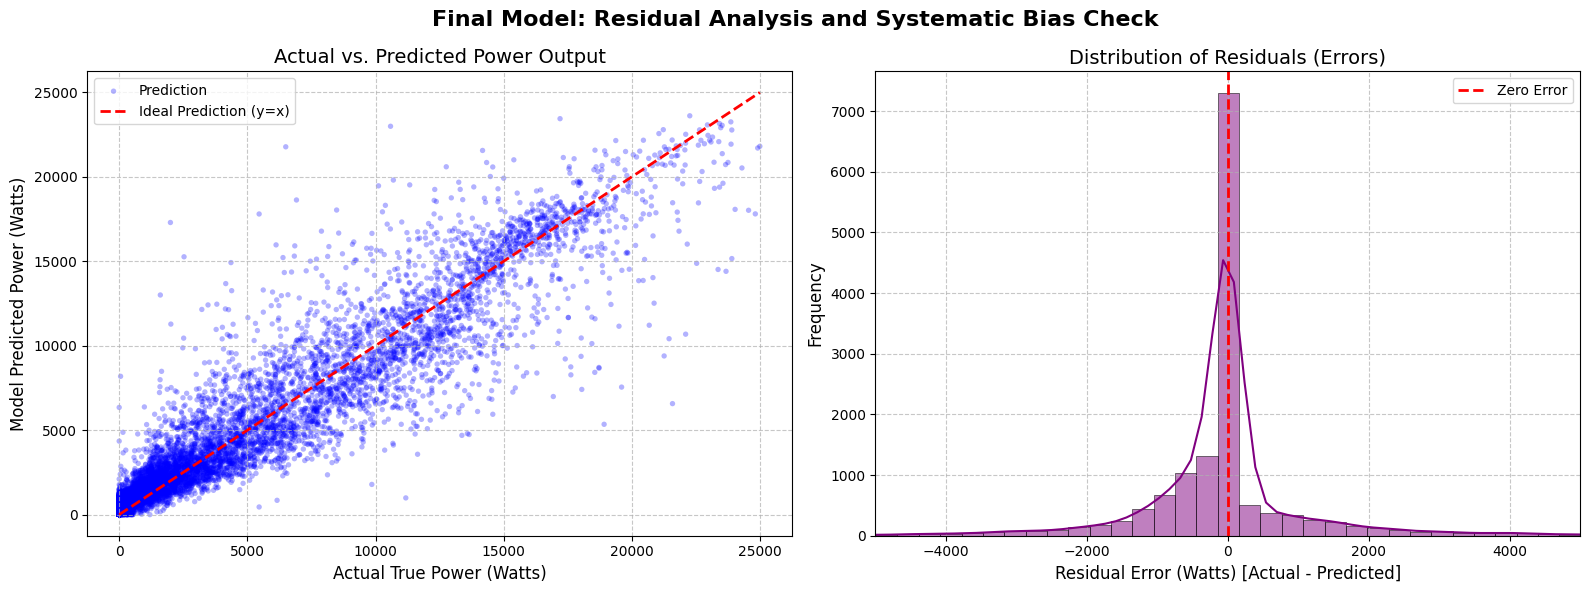

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Residuals
residuals = actuals_unscaled - preds_unscaled

# Set up the figure for side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Actual vs. Predicted Scatter Plot ---
# FIX: Removed to plot the entire arrays
axes[0].scatter(actuals_unscaled, preds_unscaled, alpha=0.3, color='blue', edgecolor='none', s=15, label = 'Prediction')

# Plot the "Perfect Accuracy" line (y = x)
max_val = max(np.max(actuals_unscaled), np.max(preds_unscaled))
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideal Prediction (y=x)')

axes[0].set_title('Actual vs. Predicted Power Output', fontsize=14)
axes[0].set_xlabel('Actual True Power (Watts)', fontsize=12)
axes[0].set_ylabel('Model Predicted Power (Watts)', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Residuals Distribution Histogram ---
# FIX 1: Removed from residuals so seaborn gets the whole array
# FIX 2: Changed ax=axes to ax=axes so it plots on the right subplot
sns.histplot(residuals, bins=100, kde=True, ax=axes[1], color='purple', edgecolor='black')

axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_title('Distribution of Residuals (Errors)', fontsize=14)
axes[1].set_xlabel('Residual Error (Watts) [Actual - Predicted]', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_xlim(-5000, 5000)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Final Model: Residual Analysis and Systematic Bias Check', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Next - model optimisation and LSTM v GRU testing

Want to test LSTM v GRU to prove which is best

For each I want to optimise all the hyperparameters:
* hidden size
* layers
* learning rate
* weight decay?
* optimiser?
* sequence length

going to use optuna and create a variable dataloader

### Part 2:

24 hours of prediction

Now using a direct multi step LSTM - sequence to vector architecture

In [ ]:
# 1. Load the newly combined dataset
df = pd.read_csv('Dataset/Time series dataset/merged_data_2021_to_2023_full.csv', index_col='Time')
df.index = pd.to_datetime(df.index, format='mixed', dayfirst=True)

# Select features and target
features = [col for col in df.columns if col != 'generation(kWh)']
target_col = 'power(W)'
target_idx = features.index(target_col)

data_array = df[features].values
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_array)

# 2. UPDATED: Multi-Step Sequence Generation
SEQ_LENGTH = 384    # Look back 96 hours
FUTURE_STEPS = 96  # Predict ahead 24 hours

def create_sequences_multistep(data, seq_length, future_steps, target_idx):
    xs, ys, indices = [], [], []
    # Stop before we run out of future steps to grab
    for i in range(len(data) - seq_length - future_steps + 1):
        xs.append(data[i : i + seq_length])
        # Grab the next 96 timesteps of the target column!
        ys.append(data[i + seq_length : i + seq_length + future_steps, target_idx])
        indices.append(df.index[i + seq_length])
    return np.array(xs), np.array(ys), indices

X, y, dates_list = create_sequences_multistep(scaled_data, SEQ_LENGTH, FUTURE_STEPS, target_idx)
dates = pd.DatetimeIndex(dates_list)

# 3. Chronological Train/Test Split
train_mask = dates < pd.Timestamp('2023-01-01')
test_mask = dates >= pd.Timestamp('2023-01-01')

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Convert to PyTorch Tensors (Notice y_train no longer needs unsqueeze(-1) because it's 2D: [Batch, 96])
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TimeSeriesDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

Above:

reloads the data gain and performs the same engineering and preprocessing as done above. 

NOTE: does not include the same updates about validation data etc as above

In [ ]:

# 4. UPDATED: Multi-Step Model
class MultiStepSolarRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(MultiStepSolarRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        # The output size is now 96
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        # Map the final hidden state to 96 distinct future points
        out = self.fc(out[:, -1, :])
        return out

INPUT_SIZE = len(features)
HIDDEN_SIZE = 128  # Increased because the task is much harder now
NUM_LAYERS = 2
OUTPUT_SIZE = FUTURE_STEPS # 96

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultiStepSolarRNN(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# 5. Training Loop
EPOCHS = 10 # Set to 25 to give it time to learn this harder task
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {running_loss / len(train_loader.dataset):.6f}")

print("Training Complete!")

Above:

Training the new model - learn more about its architecture

should perform grid search to optimise the models, hidden layers, hidden size, lr, weight decay, optimiser

also check loss value

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

model.eval()

# ==========================================
# 1. VISUALIZE A SINGLE 24-HOUR FORECAST
# ==========================================
# Let's pick a specific starting point in the 2023 test set.
# 96 steps = 1 day. Let's look at day 150 (late May - good summer generation).
DAY_INDEX = 180
START_IDX = DAY_INDEX * 96 

# Safety check just in case the test set is shorter
if START_IDX >= len(X_test_t):
    START_IDX = 0 

# Extract the specific historical input [48, Features] and true future
historical_input = X_test_t[START_IDX] 
true_future = y_test_t[START_IDX]      

# Make the Prediction for that specific moment
with torch.no_grad():
    # We add unsqueeze(0) to simulate a batch size of 1
    prediction = model(historical_input.to(device).unsqueeze(0)).squeeze(0).cpu().numpy()

historical_input_np = historical_input.numpy()
true_future_np = true_future.numpy()

# Inverse Transform the Data (Back to Watts)
num_features = len(features)

dummy_true_future = np.zeros((FUTURE_STEPS, num_features))
dummy_pred_future = np.zeros((FUTURE_STEPS, num_features))

# The history contains all features, so we can inverse transform it directly
historical_unscaled = scaler.inverse_transform(historical_input_np)[:, target_idx]

dummy_true_future[:, target_idx] = true_future_np
dummy_pred_future[:, target_idx] = prediction

true_future_unscaled = scaler.inverse_transform(dummy_true_future)[:, target_idx]
pred_future_unscaled = scaler.inverse_transform(dummy_pred_future)[:, target_idx]

# Ensure no negative predictions
pred_future_unscaled = np.maximum(pred_future_unscaled, 0)

# Create the Plot
plt.figure(figsize=(12, 6))

# Create time axes (-48 to 0 for history, 0 to 96 for future)
history_time = np.arange(-SEQ_LENGTH, 0)
future_time = np.arange(0, FUTURE_STEPS)

# Plot curves
plt.plot(history_time, historical_unscaled, label='Past 12 Hours (Actual History)', color='gray', linewidth=2)
plt.plot(future_time, true_future_unscaled, label='Next 24 Hours (Actual Future)', color='blue', linewidth=2)
plt.plot(future_time, pred_future_unscaled, label='Next 24 Hours (Predicted Future)', color='orange', linestyle='--', linewidth=2)

# Formatting
plt.axvline(x=0, color='red', linestyle=':', label='Time of Prediction (Now)')
plt.title(f'Multi-Step Solar Forecasting: 24-Hour Prediction Arc')
plt.xlabel('Time Steps (15-min intervals, 0 = Moment of Prediction)')
plt.ylabel('Power (Watts)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 2. CALCULATE OVERALL MULTI-STEP ERROR
# ==========================================
print("Calculating error metrics across the entire 2023 test set...")
all_preds = []
all_actuals = []

with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = model(inputs.to(device))
        all_preds.append(outputs.cpu().numpy())
        all_actuals.append(targets.numpy())

# Flatten all predictions and actuals
preds_array = np.concatenate(all_preds).flatten()
actuals_array = np.concatenate(all_actuals).flatten()

dummy_preds = np.zeros((len(preds_array), num_features))
dummy_actuals = np.zeros((len(actuals_array), num_features))

dummy_preds[:, target_idx] = preds_array
dummy_actuals[:, target_idx] = actuals_array

preds_unscaled = scaler.inverse_transform(dummy_preds)[:, target_idx]
actuals_unscaled = scaler.inverse_transform(dummy_actuals)[:, target_idx]
preds_unscaled = np.maximum(preds_unscaled, 0)

# Calculate MAE and NMAE
mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
peak_capacity = np.max(actuals_unscaled)
nmae = (mae / peak_capacity) * 100

print(f"\nMulti-Step Forecasting Error (Average across all 24-hour predictions in 2023):")
print(f"Mean Absolute Error (MAE): {mae:.2f} Watts")
print(f"Normalized Mean Absolute Error (NMAE): {nmae:.2f}%")

# Phase 3 - global model


To do this:
* combining all sites into one mega dataset
* taking metadata from the .ttl file
* appending metadata to each row as if it is a stable weather condition
* one model for all

In [ ]:
import re
import pandas as pd

# 1. Open the .ttl file as plain text
with open("Dataset/Metadata/PV generation system metadata.ttl", "r", encoding="utf-8") as file:
    content = file.read()

# 2. Split the text into blocks for each site
blocks = content.split("pvsystem:")

metadata_list = []

for block in blocks:
    # We only care about the blocks defining Solar Panels
    if "a brick:PV_Panel" in block:
        
        # Extract the raw internal name (e.g., Zone_L1__Station_2__Module)
        raw_name = block.split(" ")[0].strip()
        
        # Search for the Number of Panels
        num_match = re.search(r'ext:number \[ brick:value (\d+)', block)
        num_panels = float(num_match.group(1)) if num_match else 0.0
        
        # Search for the Efficiency
        eff_match = re.search(r'ext:ratedModuleConversionEfficiency \[ brick:value ([\d\.]+)', block)
        efficiency = float(eff_match.group(1)) if eff_match else 0.0
        
        # Search for the Power Per Panel (Watts) - handling newlines in the block
        pow_match = re.search(r'ext:ratedPowerOutput \[.*?brick:value ([\d\.]+)', block, re.DOTALL)
        power_w = float(pow_match.group(1)) if pow_match else 0.0
        
        # Clean up the name to roughly match your CSV folder names
        clean_name = raw_name.replace('__Module', '').replace('__', ' (').replace('_', ' ')
        if '(' in clean_name and ')' not in clean_name:
            clean_name += ')'
            
        metadata_list.append({
            'Site_Name_Est': clean_name,
            'Num_Panels': num_panels,
            'Efficiency': efficiency,
            'Power_Per_Panel_W': power_w,
            'Total_Capacity_W': num_panels * power_w
        })

# 3. Save it to a clean CSV
df_metadata = pd.DataFrame(metadata_list)
df_metadata.to_csv('extracted_site_metadata.csv', index=False)

print(f"Successfully extracted metadata for {len(df_metadata)} sites!")
df_metadata

In [ ]:
import pandas as pd
import numpy as np
import os
import glob
import difflib  # Built-in library for fuzzy string matching

# 1. Load the Metadata
df_meta = pd.read_csv('extracted_site_metadata.csv')
meta_names = df_meta['Site_Name_Est'].tolist()

# 2. Load the Weather Data
weather_df = pd.read_csv('Dataset/Time series dataset/merged_data_2021_to_2023_full.csv', index_col='Time')
weather_df.index = pd.to_datetime(weather_df.index, format='mixed', dayfirst=True)
weather_df = weather_df.drop(columns=['generation(kWh)', 'power(W)'])

# 3. Define paths to your PV station folders (Keep your existing base_path here)
base_path = r"Dataset/Time series dataset/PV generation dataset" 
opt_path = os.path.join(base_path, "PV stations with panel level optimizer", "Site level dataset", "*.csv")
no_opt_path = os.path.join(base_path, "PV stations without panel level optimizer", "Site level dataset", "*.csv")

all_site_files = glob.glob(opt_path) + glob.glob(no_opt_path)
all_sites_data = []

print(f"Found {len(all_site_files)} site files. Building Mega-Dataset...")

# 4. Loop through every site and build the dataset
for file in all_site_files:
    filename = os.path.basename(file)
    site_name = filename.replace('.csv', '')
    
    has_optimizer = 1 if "with panel level optimizer" in file and "without" not in file else 0
    
    # --- NEW: FUZZY MATCHING ---
    # Find the closest matching name in the metadata list (cutoff 0.4 means 40% similarity required)
    best_matches = difflib.get_close_matches(site_name, meta_names, n=1, cutoff=0.4)
    
    if best_matches:
            # FIX 1: Add to extract the string from the list
            matched_name = best_matches[0]
            
            # FIX 2: Add to iloc to extract the single row as a Series
            row = df_meta[df_meta['Site_Name_Est'] == matched_name].iloc[0]
            
            capacity = row['Total_Capacity_W']
            efficiency = row['Efficiency']
            print(f"Matched CSV '{site_name}' ---> Metadata '{matched_name}' (Cap: {capacity}W)")
    else:
            print(f"CRITICAL WARNING: No match at all for '{site_name}'. Defaulting to 0.")
            capacity = 0.0
            efficiency = 0.0
        
    # Read the specific site's power data
    try:
        site_df = pd.read_csv(file, parse_dates=['Time'])
        site_df.set_index('Time', inplace=True)
        
        # Fixed the Pandas warning here!
        site_df = site_df.resample('15min').mean()
        
        merged_site = site_df.join(weather_df, how='inner')
        merged_site.dropna(inplace=True)
        
        merged_site['Has_Optimizer'] = has_optimizer
        merged_site['Total_Capacity_W'] = capacity
        merged_site['Efficiency'] = efficiency
        merged_site['Site_ID'] = site_name
        
        all_sites_data.append(merged_site)
        
    except Exception as e:
        print(f"Error processing {filename}: {e}")

# 5. Concatenate everything into one massive table
if len(all_sites_data) > 0:
    mega_dataset = pd.concat(all_sites_data, axis=0)
    print(f"\nMega-Dataset complete! Total rows: {len(mega_dataset)}")
    
    # Save as Pickle
    mega_dataset.to_pickle('Global_Mega_Dataset.pkl')
    print("Saved as 'Global_Mega_Dataset.pkl'")
else:
    print("No data was merged.")

In [ ]:
mega_dataset.head()

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import gc # Garbage collector

print("Loading Mega-Dataset...")
df = mega_dataset

# 1. Aggressive Memory Downcasting (Cuts RAM usage in half!)
for col in df.columns:
    if df[col].dtype == 'float64':
        df[col] = df[col].astype(np.float32)

df.drop(columns=['generation(kWh)'], inplace=True, errors='ignore')

# 2. In-Place Sorting (Prevents duplicating the dataframe)
# Give the column a temporary name so Pandas doesn't get confused with the index
df['Time_Col'] = df.index
df.sort_values(by=['Site_ID', 'Time_Col'], inplace=True)

# Drop the temporary column (the index remains safely attached and sorted!)
df.drop(columns=['Time_Col'], inplace=True)

# 3. Select the "Unseen" Test Site
TEST_SITE = "Zone A1" 
print(f"Holding out '{TEST_SITE}' for testing...")

train_df = df[df['Site_ID'] != TEST_SITE].copy()
test_df = df[df['Site_ID'] == TEST_SITE].copy()

# Free up the original massive dataframe to get our RAM back!
del df 
gc.collect()

features = train_df.select_dtypes(include=[np.number]).columns.tolist()

target_col = 'power(W)'
target_idx = features.index(target_col)

# 4. Fit Scaler ONLY on Training Data
print("Scaling data...")
scaler = MinMaxScaler()
scaler.fit(train_df[features].values)

# 5. Memory-Efficient Custom Dataset (Lazy Loading)
class LazySolarDataset(Dataset):
    def __init__(self, dataframe, features, target_idx, seq_length, scaler):
        self.seq_length = seq_length
        self.target_idx = target_idx
        
        # Scale the data and force it back to float32
        self.data = scaler.transform(dataframe[features].values).astype(np.float32)
        
        # Precompute valid start indices
        self.valid_indices = []
        current_start = 0
        site_counts = dataframe.groupby('Site_ID', sort=False).size()
        
        for count in site_counts:
            if count > seq_length:
                self.valid_indices.extend(range(current_start, current_start + count - seq_length))
            current_start += count
            
        self.valid_indices = np.array(self.valid_indices, dtype=np.int32)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start = self.valid_indices[idx]
        x = self.data[start : start + self.seq_length]
        y = self.data[start + self.seq_length, self.target_idx]
        return torch.tensor(x), torch.tensor([y])

SEQ_LENGTH = 48 # 12 hours

print("Initializing Memory-Efficient Datasets...")
train_dataset = LazySolarDataset(train_df, features, target_idx, SEQ_LENGTH, scaler)
test_dataset = LazySolarDataset(test_df, features, target_idx, SEQ_LENGTH, scaler)

# Free up the dataframes now that the Datasets have them
del train_df
del test_df
gc.collect()

print(f"Total training sequences available: {len(train_dataset)}")
print(f"Total testing sequences available: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

# 6. The Universal LSTM Model
class UniversalSolarRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(UniversalSolarRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

INPUT_SIZE = len(features) 
HIDDEN_SIZE = 64
NUM_LAYERS = 2
OUTPUT_SIZE = 1

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")
model = UniversalSolarRNN(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 7. Training Loop
EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {running_loss / len(train_dataset):.6f}")

# 8. Final Generalization Test
model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        test_loss += criterion(outputs, targets).item() * inputs.size(0)

print(f"\nFinal Unseen Site '{TEST_SITE}' MSE Loss: {test_loss / len(test_dataset):.6f}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Final Generalization Test & Data Gathering
model.eval()
all_preds = []
all_actuals = []

print(f"\nEvaluating on unseen site: {TEST_SITE}...")
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        all_preds.append(outputs.cpu().numpy())
        all_actuals.append(targets.numpy())

# Flatten arrays
preds_array = np.concatenate(all_preds).flatten()
actuals_array = np.concatenate(all_actuals).flatten()

# 2. Inverse Transform back to Watts
# Create dummy arrays to trick the scaler into unscaling our 1D power arrays
dummy_preds = np.zeros((len(preds_array), len(features)))
dummy_actuals = np.zeros((len(actuals_array), len(features)))

dummy_preds[:, target_idx] = preds_array
dummy_actuals[:, target_idx] = actuals_array

preds_unscaled = scaler.inverse_transform(dummy_preds)[:, target_idx]
actuals_unscaled = scaler.inverse_transform(dummy_actuals)[:, target_idx]

# Neural networks sometimes predict slight negative numbers at night. Clamp them to 0.
preds_unscaled = np.maximum(preds_unscaled, 0)

# Calculate final real-world metrics
mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
peak_capacity = np.max(actuals_unscaled)
nmae = (mae / peak_capacity) * 100

print(f"--- Universal Model Generalization Results ({TEST_SITE}) ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} W")
print(f"Normalized Mean Absolute Error (NMAE): {nmae:.2f}%\n")

# 3. VISUALIZATION: Time Series Prediction on Unseen Site (Slice of 4 Days)
# 96 steps = 1 day. Let's look at 4 days of data. 
# We'll skip the first few thousand steps to get into the sunny summer months
START_IDX = 4000  
STEPS_TO_SHOW = 96 * 4  
END_IDX = START_IDX + STEPS_TO_SHOW

# Safety check just in case the test set is unexpectedly short
if END_IDX > len(actuals_unscaled):
    START_IDX = 0
    END_IDX = min(len(actuals_unscaled), 96 * 4)

plt.figure(figsize=(14, 6))
plt.plot(actuals_unscaled[START_IDX:END_IDX], label=f'Actual Power ({TEST_SITE})', color='blue', linewidth=2)
plt.plot(preds_unscaled[START_IDX:END_IDX], label=f'Predicted Power (Using Global Model)', color='orange', linestyle='--', linewidth=2)

plt.title(f'Generalization Test: Predicting 4 Days of Power for Unseen Site ({TEST_SITE})')
plt.xlabel('Time Steps (15-Minute Intervals)')
plt.ylabel('Power Output (Watts)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Final Generalization Test & Data Gathering
model.eval()
all_preds = []
all_actuals = []
all_irradiances = [] # NEW: We will track the sunlight!

# Find which column index holds the Irradiance data
irradiance_idx = features.index('Irradiance (W/m2)')

print(f"\nEvaluating on unseen site: {TEST_SITE}...")
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        all_preds.append(outputs.cpu().numpy())
        all_actuals.append(targets.numpy())
        
        # Grab the scaled Irradiance from the very last timestep of the input sequence
        all_irradiances.append(inputs[:, -1, irradiance_idx].cpu().numpy())

# Flatten arrays
preds_array = np.concatenate(all_preds).flatten()
actuals_array = np.concatenate(all_actuals).flatten()
irradiance_array = np.concatenate(all_irradiances).flatten()

# 2. Inverse Transform back to Watts
dummy_preds = np.zeros((len(preds_array), len(features)))
dummy_actuals = np.zeros((len(actuals_array), len(features)))

dummy_preds[:, target_idx] = preds_array
dummy_actuals[:, target_idx] = actuals_array

preds_unscaled = scaler.inverse_transform(dummy_preds)[:, target_idx]
actuals_unscaled = scaler.inverse_transform(dummy_actuals)[:, target_idx]

# ---------------------------------------------------------
# THE MAGIC FIX: PHYSICS-INFORMED MASKING
# ---------------------------------------------------------
# If the scaled Irradiance is less than 1% (meaning it is dark), 
# override the neural network and force the prediction to 0 Watts.
night_mask = irradiance_array < 0.01 
preds_unscaled[night_mask] = 0.0

# Still clamp any other weird negative predictions during the day to 0
preds_unscaled = np.maximum(preds_unscaled, 0)
# ---------------------------------------------------------

# Calculate final real-world metrics
mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
peak_capacity = np.max(actuals_unscaled)
nmae = (mae / peak_capacity) * 100

print(f"--- Universal Model Generalization Results ({TEST_SITE}) ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} W")
print(f"Normalized Mean Absolute Error (NMAE): {nmae:.2f}%\n")

# 3. VISUALIZATION: Time Series Prediction on Unseen Site (Slice of 4 Days)
START_IDX = 4000  
STEPS_TO_SHOW = 96 * 4  
END_IDX = START_IDX + STEPS_TO_SHOW

if END_IDX > len(actuals_unscaled):
    START_IDX = 0
    END_IDX = min(len(actuals_unscaled), 96 * 4)

plt.figure(figsize=(14, 6))
plt.plot(actuals_unscaled[START_IDX:END_IDX], label=f'Actual Power ({TEST_SITE})', color='blue', linewidth=2)
plt.plot(preds_unscaled[START_IDX:END_IDX], label=f'Predicted Power (Using Global Model)', color='orange', linestyle='--', linewidth=2)

plt.title(f'Generalization Test: Predicting 4 Days of Power for Unseen Site ({TEST_SITE})')
plt.xlabel('Time Steps (15-Minute Intervals)')
plt.ylabel('Power Output (Watts)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()